<a href="https://colab.research.google.com/github/sanika8202/Tomato-Leaf-Disease-Detection-CNN/blob/main/Tomato_Leaf_Disease_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("pytorch version",torch.__version__)
print("GPU available",torch.cuda.is_available())

pytorch version 2.11.0+cpu
GPU available False


In [3]:
import zipfile

zip_path = "/content/Tomato-dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

In [14]:
import os

dataset_path = "/content/Tomato-dataset"

print(os.listdir(dataset_path))

['Spider_mite', 'Mosaic_virus', 'Yellow_Leaf_Curl_Virus', 'Bacterial_spot', 'Early_blight', 'Target_Spot', 'Leaf_Mold', 'Septoria_leaf_spot', 'Late_blight', 'healthy']


In [15]:
for folder in ["healthy", "Early_blight", "Late_blight"]:
    path = os.path.join(dataset_path, folder)
    print(folder, ":", len(os.listdir(path)), "images")

healthy : 100 images
Early_blight : 100 images
Late_blight : 100 images


In [16]:
import torch
from torchvision import datasets, transforms

In [17]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [18]:
import os
import shutil

source = dataset_path
target = "/content/tomato_3_classes"

classes = ["healthy", "Early_blight", "Late_blight"]

for cls in classes:
    source_folder = os.path.join(source, cls)
    target_folder = os.path.join(target, cls)

    os.makedirs(target_folder, exist_ok=True)

    for file in os.listdir(source_folder):
        shutil.copy(
            os.path.join(source_folder, file),
            os.path.join(target_folder, file)
        )

print("3 classes copied successfully!")

3 classes copied successfully!


In [19]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [20]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    "/content/tomato_3_classes",
    transform=transform
)

In [22]:
print(dataset.classes)
print("Total images:", len(dataset))

['Early_blight', 'Late_blight', 'healthy']
Total images: 300


In [23]:
image, label = dataset[0]

print("Image:", image)
print("Label:", label)

Image: tensor([[[0.7176, 0.7216, 0.7098,  ..., 0.6902, 0.6941, 0.6980],
         [0.7216, 0.7294, 0.6941,  ..., 0.6824, 0.7098, 0.7137],
         [0.7255, 0.7373, 0.7020,  ..., 0.6627, 0.6941, 0.7020],
         ...,
         [0.4667, 0.4902, 0.4706,  ..., 0.5098, 0.4745, 0.4667],
         [0.4667, 0.5255, 0.4863,  ..., 0.4824, 0.4471, 0.4549],
         [0.4588, 0.5216, 0.4824,  ..., 0.5059, 0.4588, 0.4706]],

        [[0.6784, 0.6824, 0.6706,  ..., 0.6667, 0.6706, 0.6745],
         [0.6824, 0.6902, 0.6549,  ..., 0.6588, 0.6863, 0.6902],
         [0.6863, 0.6980, 0.6627,  ..., 0.6392, 0.6706, 0.6784],
         ...,
         [0.4196, 0.4431, 0.4275,  ..., 0.4824, 0.4471, 0.4392],
         [0.4314, 0.4706, 0.4118,  ..., 0.4431, 0.4078, 0.4196],
         [0.4275, 0.4627, 0.3922,  ..., 0.4588, 0.4157, 0.4275]],

        [[0.6745, 0.6784, 0.6667,  ..., 0.6667, 0.6706, 0.6745],
         [0.6784, 0.6863, 0.6510,  ..., 0.6588, 0.6863, 0.6902],
         [0.6824, 0.6941, 0.6588,  ..., 0.6392, 0.6

In [24]:
print("Image shape:", image.shape)

Image shape: torch.Size([3, 128, 128])


In [25]:
print(dataset.classes)

['Early_blight', 'Late_blight', 'healthy']


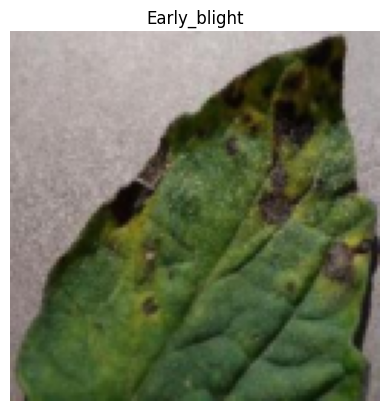

In [26]:
import matplotlib.pyplot as plt

image, label = dataset[0]

plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [27]:
from torch.utils.data import DataLoader

In [28]:
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [30]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


In [31]:
import torch
import torch.nn as nn

In [32]:
class TomatoCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3)
        self.pool = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)

        self.fc = nn.Linear(32 * 30 * 30, 3)

In [33]:
    def forward(self, x):
        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [34]:
# Model create
model = TomatoCNN()

print(model)

TomatoCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc): Linear(in_features=28800, out_features=3, bias=True)
)


In [36]:
import torch
import torch.nn as nn

# Redefine the full class with the forward method in one place
class TomatoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.fc = nn.Linear(32 * 30 * 30, 3)

    def forward(self, x):
        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Re-instantiate the model
model = TomatoCNN()

# Get a batch of images and pass it through the model
images, labels = next(iter(train_loader))
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 3])


In [37]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [38]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [39]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    for images, labels in train_loader:

        # Prediction
        outputs = model(images)

        # Loss calculate
        loss = criterion(outputs, labels)

        # remove old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Weights update
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/5], Loss: 1.1461
Epoch [2/5], Loss: 1.1090
Epoch [3/5], Loss: 0.5216
Epoch [4/5], Loss: 0.3693
Epoch [5/5], Loss: 0.4356


In [40]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in train_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Accuracy:", accuracy, "%")

Accuracy: 86.0 %


In [42]:
from google.colab import files

uploaded = files.upload()

Saving test.jpg to test.jpg


In [43]:
from PIL import Image
from torchvision import transforms

image = Image.open(list(uploaded.keys())[0]).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image_tensor = transform(image)

print("Image shape:", image_tensor.shape)

Image shape: torch.Size([3, 128, 128])


In [44]:
image_tensor = image_tensor.unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(image_tensor)

print("Output:", output)

Output: tensor([[-0.1159, -0.2189,  1.4579]])


In [45]:
_, predicted = torch.max(output, 1)

predicted_class = dataset.classes[predicted.item()]

print("Predicted Class:", predicted_class)

Predicted Class: healthy
